# 01fi · Integration with scVI (**Monocytes, macrophages, cDC2** visualisation manifold, acrosslifespan/noEMC)

This script generates the integrated .h5ad object necessary for generating **Extended Data Figure 4d.**

**Pipeline:**
1. Extract target barcodes from annotation `.csv`
2. For each postnatal h5ad: load → subset to target barcodes → save to a dedicated temp folder
3. Concatenate subsetted files on-disk: `join='outer'` (union of genes) and `join='inner'` (shared genes)
4. Inner concat → HVGs (`seurat_v3`) → scVI (`Dataset` batch, `Donor_id` covariate)
5. Transfer `X_scVI` to outer concat → KNN → UMAP → Leiden
6. Save integrated object

## Configuration

In [21]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
MAIN_DIR   = "/nfs/team292/projects/PanTissue/"
INPUT_DIR  = os.path.join(MAIN_DIR, "results/temp/anndata_copy_freeze/")

# Annotation CSV
ANNOTATION_CSV = os.path.join(MAIN_DIR, "results/temp/02_annotation/immune/acrosslifespan/noHormones/20260514_acrosslifespan_noHormones_immune_annotations.csv")
LINEAGE_COL    = "celltype_HCA"
LINEAGE_TARGET = [
    "Immune_MO_Classical",
    "Immune_MO_NonClassical",
    
    "Immune_Mac_LYVE1hi",
    "Immune_Mac_Transitional",
    "Immune_uftLAM",
    "Immune_oLAM",
    "Immune_uMac_Inf",
    "Immune_Mac_Cyc",
    
    "Immune_cDC2",
    "Immune_cDC2_CD207hi",
    "Immune_tolDC",
]

# selected_menstrual_stages = ['Proliferative', 'Secretory', 'Menstrual', 'Postmenopausal', 'Postmenopause', 'Unknown', 'Paediatric', 'Peripubertal', 'Not']

# Temporary folder for per-dataset subsetted h5ads (created here, used for concat)
SUBSET_DIR = os.path.join(MAIN_DIR, "results/temp/00_preprocessing_acrosslifespan_noHormones_immune_monomacscDC2_visualisation/")

# Integration outputs
OUTPUT_DIR        = os.path.join(MAIN_DIR, "results/temp/01_integration/")
CONCAT_H5AD_OUTER = os.path.join(OUTPUT_DIR, "concat_acrosslifespan_noHormones_immune_monomacscDC2_visualisation_outer.h5ad")
CONCAT_H5AD_INNER = os.path.join(OUTPUT_DIR, "concat_acrosslifespan_noHormones_immune_monomacscDC2_visualisation_inner.h5ad")
INTEGRATED_H5AD   = os.path.join(OUTPUT_DIR, "integrated_scvi_acrosslifespan_noHormones_immune_monomacscDC2_visualisation.h5ad")
SCVI_MODEL_DIR    = os.path.join(OUTPUT_DIR, "scvi_model_acrosslifespan_noHormones_immune_monomacscDC2_visualisation")

os.makedirs(SUBSET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── HVG parameters ───────────────────────────────────────────────────────────
N_HVG      = 2000   # fewer cells → fewer HVGs to avoid over-fitting
HVG_FLAVOR = "seurat_v3"
HVGs_BATCH_COL   = "L3"  # column used as batch key for HVGs calculation

# ── scVI batch Column names in obs ───────────────────────────────────────────────────────
DATASET_COL      = "Dataset"   # batch key for scVI
DONOR_COL        = "Donor_id"  # covariate key for scVI
CELL_CYCLE_PHASE = "phase"     # covariate key for scVI

# ── scVI parameters ───────────────────────────────────────────────────────────
N_LATENT        = 60
N_LAYERS        = 1
GENE_LIKELIHOOD = "nb"
MAX_EPOCHS      = 200
EARLY_STOPPING  = True
DISPERSION      = 'gene-batch' #gene-batch

# ── Neighbours / UMAP parameters ─────────────────────────────────────────────
N_NEIGHBORS       = 20
LEIDEN_RESOLUTION = 2

# ── Misc ─────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_CPUS      = 8

## Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import gc
import glob as glob_mod

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import scvi
from anndata.experimental import concat_on_disk

sc.settings.verbosity = 3
sc.settings.n_jobs    = N_CPUS
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))
ad.settings.allow_write_nullable_strings = True

print(f"anndata  : {ad.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"scvi     : {scvi.__version__}")

anndata  : 0.12.6
scanpy   : 1.12
scvi     : 1.4.2


## 1 · Load annotation and identify immune barcodes

In [3]:
if not os.path.exists(ANNOTATION_CSV):
    raise FileNotFoundError(
        f"Annotation CSV not found: {ANNOTATION_CSV}\n"
        "Run 03_annotation_postnatal.ipynb first."
    )

ann = pd.read_csv(ANNOTATION_CSV, index_col="barcode")
print(f"Annotation CSV loaded: {len(ann):,} cells total")
print(f"\nLineage distribution:")
print(ann[LINEAGE_COL].value_counts())

Annotation CSV loaded: 228,611 cells total

Lineage distribution:
celltype_HCA
Immune_CD8_T_RM_GZMKhi                25502
Immune_uMac_Inf                       23069
Immune_Mac_LYVE1hi                    16783
Immune_CD8_T_RM                       15131
Immune_MO_Classical                   13759
Immune_CD4_T_Unpolarised              13177
Immune_uNK2                           12245
Immune_uNK3                           10688
Immune_CD4_Th17                        6802
Immune_CD4_NaiveT                      6169
doublet                                5789
Immune_Mast                            5449
Immune_NK_CD16hi                       5175
Immune_CD4_Th17_SCMlike                5130
Immune_MemoryB                         4542
Immune_CD8_T_EM                        4022
Immune_MAIT                            3733
Immune_CD4_Treg                        3695
Immune_uNK1                            3543
Immune_NK_Cyc                          3503
Immune_cDC2                            34

In [4]:
selected_barcodes = set(ann.index[ann[LINEAGE_COL].isin(LINEAGE_TARGET)])
lineage_str = ", ".join(LINEAGE_TARGET)
print(f"{lineage_str} barcodes identified: {len(selected_barcodes):,}")

Immune_MO_Classical, Immune_MO_NonClassical, Immune_Mac_LYVE1hi, Immune_Mac_Transitional, Immune_uftLAM, Immune_oLAM, Immune_uMac_Inf, Immune_Mac_Cyc, Immune_cDC2, Immune_cDC2_CD207hi, Immune_tolDC barcodes identified: 68,198


## 2 · Subset individual h5ads

Each postnatal dataset is loaded individually, subset to immune barcodes, and saved to `SUBSET_DIR`.  
This keeps peak memory proportional to a single dataset rather than the full atlas.

In [5]:
# ── Discover source h5ads ───────────────────────────────────────────────
all_paths = sorted(glob_mod.glob(os.path.join(INPUT_DIR, "*.h5ad")))
source_paths = all_paths

if len(source_paths) == 0:
    raise FileNotFoundError(
        f"No h5ad files found in {INPUT_DIR}\n"
        "Expected filenames containing '.h5ad'."
    )

print(f"Source datasets ({len(source_paths)}):")
for p in source_paths:
    print(f"  {os.path.basename(p)}")

Source datasets (27):
  cervix_adult_Guo2023-denoised.h5ad
  fallopiantube_adult_sanger-denoised.h5ad
  fallopiantube_adult_urlich2022-denoised.h5ad
  fallopiantube_adult_weigert2025-denoised.h5ad
  gonad_fetal_lardenois2026-denoised.h5ad
  gonad_fetal_taelman2024-denoised.h5ad
  ovary_adult_gaylord2025-denoised.h5ad
  ovary_adult_guahmich2023-denoised.h5ad
  ovary_adult_jones2024-denoised.h5ad
  ovary_adult_sanger-denoised.h5ad
  ovary_adult_wagner2020-denoised.h5ad
  ovary_fetal_garciaalonso2022-denoised.h5ad
  ovary_fetal_wamaitah-denoised.h5ad
  ovary_paediatric_sanger-denoised.h5ad
  reptract_fetal_lorenzi2025-denoised.h5ad
  uterus_adult_Huang2023-denoised.h5ad
  uterus_adult_Liu2025-denoised.h5ad
  uterus_adult_Wang2020-denoised.h5ad
  uterus_adult_burns2026-denoised.h5ad
  uterus_adult_garciaalonso2021-denoised.h5ad
  uterus_adult_mareckova2024-denoised.h5ad
  uterus_adult_menstrualfluid_sanger-denoised.h5ad
  uterus_adult_sanger-denoised.h5ad
  uterus_adult_tan2022-denoised.h5

In [6]:
skipped = []

for src_path in source_paths:
    name     = os.path.splitext(os.path.basename(src_path))[0]
    out_path = os.path.join(SUBSET_DIR, f"{name}.h5ad")

    if os.path.exists(out_path):
        print(f"  {name}: subset already exists — skipping.")
        continue

    print(f"  {name}: loading …", end=" ", flush=True)
    adata = ad.read_h5ad(src_path)
    
    # 1. Select barcodes in selected_barcodes
    combined_mask = adata.obs_names.isin(selected_barcodes)
    
    # 2. Add Menstrual Stage filter ONLY if the list is not None
    # if selected_menstrual_stages is not None:
    #     adata.obs["Menstrual_stage_short"] = (
    #         adata.obs['Menstrual_stage'].astype(str).str.split(" ").str[0]
    #     )
    #     mask_stage = adata.obs.Menstrual_stage_short.isin(selected_menstrual_stages)
    #     combined_mask &= mask_stage  # Update mask with AND logic
    
    n_keep = int(combined_mask.sum())
    print(f"{adata.n_obs:,} cells → {n_keep:,} kept", end=" ", flush=True)

    if n_keep < 5:
        print(f"— < 5 cells after filtering, skipping.")
        skipped.append(name)
        del adata
        gc.collect()
        continue

    # Subset and save
    adata_subset = adata[combined_mask].copy()
    del adata
    gc.collect()

    adata_subset.write_h5ad(out_path)
    print(f"→ saved.")
    del adata_subset
    gc.collect()

print(f"\nDone. Skipped datasets: {skipped if skipped else 'none'}")

  cervix_adult_Guo2023-denoised: loading … 15,403 cells → 665 kept → saved.
  fallopiantube_adult_sanger-denoised: loading … 54,078 cells → 4,821 kept → saved.
  fallopiantube_adult_urlich2022-denoised: loading … 64,195 cells → 3,407 kept → saved.
  fallopiantube_adult_weigert2025-denoised: loading … 180,440 cells → 7,332 kept → saved.
  gonad_fetal_lardenois2026-denoised: loading … 73,420 cells → 378 kept → saved.
  gonad_fetal_taelman2024-denoised: loading … 2,083 cells → 16 kept → saved.
  ovary_adult_gaylord2025-denoised: loading … 57,923 cells → 344 kept → saved.
  ovary_adult_guahmich2023-denoised: loading … 45,561 cells → 688 kept → saved.
  ovary_adult_jones2024-denoised: loading … 27,596 cells → 434 kept → saved.
  ovary_adult_sanger-denoised: loading … 141,904 cells → 537 kept → saved.
  ovary_adult_wagner2020-denoised: loading … 32,763 cells → 53 kept → saved.
  ovary_fetal_garciaalonso2022-denoised: loading … 260,744 cells → 5,716 kept → saved.
  ovary_fetal_wamaitah-denois

## 3 · Concatenate subsetted files on disk

In [7]:
# ── Collect the subsetted h5ads ───────────────────────────────────────────────
subset_paths = sorted(glob_mod.glob(os.path.join(SUBSET_DIR, "*.h5ad")))

if len(subset_paths) == 0:
    raise FileNotFoundError(f"No subsetted h5ad files found in {SUBSET_DIR}")

in_files = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in subset_paths
}

print(f"Datasets to concatenate ({len(in_files)}):")
for k, v in in_files.items():
    print(f"  {k:50s}  {v}")

Datasets to concatenate (27):
  cervix_adult_Guo2023-denoised                       /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_acrosslifespan_noHormones_immune_monomacscDC2_visualisation/cervix_adult_Guo2023-denoised.h5ad
  fallopiantube_adult_sanger-denoised                 /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_acrosslifespan_noHormones_immune_monomacscDC2_visualisation/fallopiantube_adult_sanger-denoised.h5ad
  fallopiantube_adult_urlich2022-denoised             /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_acrosslifespan_noHormones_immune_monomacscDC2_visualisation/fallopiantube_adult_urlich2022-denoised.h5ad
  fallopiantube_adult_weigert2025-denoised            /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_acrosslifespan_noHormones_immune_monomacscDC2_visualisation/fallopiantube_adult_weigert2025-denoised.h5ad
  gonad_fetal_lardenois2026-denoised                  /nfs/team292/projects/PanTissue/results/temp/

In [8]:
# ── Outer concat (union of genes) ────────────────────────────────────────────
if os.path.exists(CONCAT_H5AD_OUTER):
    print(f"Outer concat already exists: {CONCAT_H5AD_OUTER}\nSkipping.")
else:
    print("Concatenating (outer — union of genes) …")
    concat_on_disk(
        in_files = in_files,
        out_file = CONCAT_H5AD_OUTER,
        join     = "outer",
        label    = DATASET_COL,
    )
    print(f"Saved → {CONCAT_H5AD_OUTER}")

# ── Inner concat (intersection of genes) ─────────────────────────────────────
if os.path.exists(CONCAT_H5AD_INNER):
    print(f"Inner concat already exists: {CONCAT_H5AD_INNER}\nSkipping.")
else:
    print("Concatenating (inner — intersection of genes) …")
    concat_on_disk(
        in_files = in_files,
        out_file = CONCAT_H5AD_INNER,
        join     = "inner",
        label    = DATASET_COL,
    )
    print(f"Saved → {CONCAT_H5AD_INNER}")

Concatenating (outer — union of genes) …
Saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/concat_acrosslifespan_noHormones_immune_monomacscDC2_visualisation_outer.h5ad
Concatenating (inner — intersection of genes) …
Saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/concat_acrosslifespan_noHormones_immune_monomacscDC2_visualisation_inner.h5ad


In [9]:
print("Loading inner concat (intersection of genes) …")
adata_inner = ad.read_h5ad(CONCAT_H5AD_INNER)

# ── Guard against duplicate barcodes ─────────────────────────────────────────
dup_mask = adata_inner.obs_names.duplicated()
if dup_mask.any():
    n_dup = int(dup_mask.sum())
    print(f"WARNING: {n_dup} duplicate barcodes — deduplicating (keeping first).")
    adata_inner = adata_inner[~dup_mask].copy()

# ── Fix sparse matrix dtype mismatch (concat_on_disk can mix int32/int64) ────
if sp.issparse(adata_inner.X) and adata_inner.X.indptr.dtype != adata_inner.X.indices.dtype:
    target_dtype = np.result_type(adata_inner.X.indptr.dtype, adata_inner.X.indices.dtype)
    print(f"Fixing sparse dtype mismatch: indptr={adata_inner.X.indptr.dtype}, "
          f"indices={adata_inner.X.indices.dtype} → {target_dtype}")
    adata_inner.X.indptr  = adata_inner.X.indptr.astype(target_dtype)
    adata_inner.X.indices = adata_inner.X.indices.astype(target_dtype)

print(f"inner : {adata_inner.n_obs:,} cells × {adata_inner.n_vars:,} genes")
print("\nobs columns:", adata_inner.obs.columns.tolist())

Loading inner concat (intersection of genes) …
inner : 68,198 cells × 15,364 genes

obs columns: ['n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors']


## 4 · Highly variable genes stratified by menstrual stage

In [11]:
sc.pp.filter_genes(adata_inner, min_cells=5)

filtered out 26 genes that are detected in less than 5 cells


In [16]:
# Add HVGs_BATCH_COL to adata_inner if not already present
if HVGs_BATCH_COL not in adata_inner.obs:
    
    if HVGs_BATCH_COL and HVGs_BATCH_COL in ann.columns:
        print(f"Extracting batch key '{HVGs_BATCH_COL}' from ANNOTATION_CSV and adding to adata_inner...")
        to_merge = ann[[HVGs_BATCH_COL]]

        new_obs = adata_inner.obs.merge(
            to_merge, 
            how='left',
            left_index=True,
            right_on="barcode"
        )

        new_obs.index = adata_inner.obs.index
        adata_inner.obs = new_obs
        print(f">> Batch key added!")
        
    else:
        print(f"WARNING: Batch key '{HVGs_BATCH_COL}' not present in ANNOTATION_CSV.")
        
else:
    print(f"Batch key '{HVGs_BATCH_COL}' already in adata_inner, proceeding to HVG identification.")

Extracting batch key 'L3' from ANNOTATION_CSV and adding to adata_inner...
>> Batch key added!


Identifying 2000 HVGs on inner concat (15,338 shared genes) …
Running HVG with batch key: L3
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVGs selected: 2000


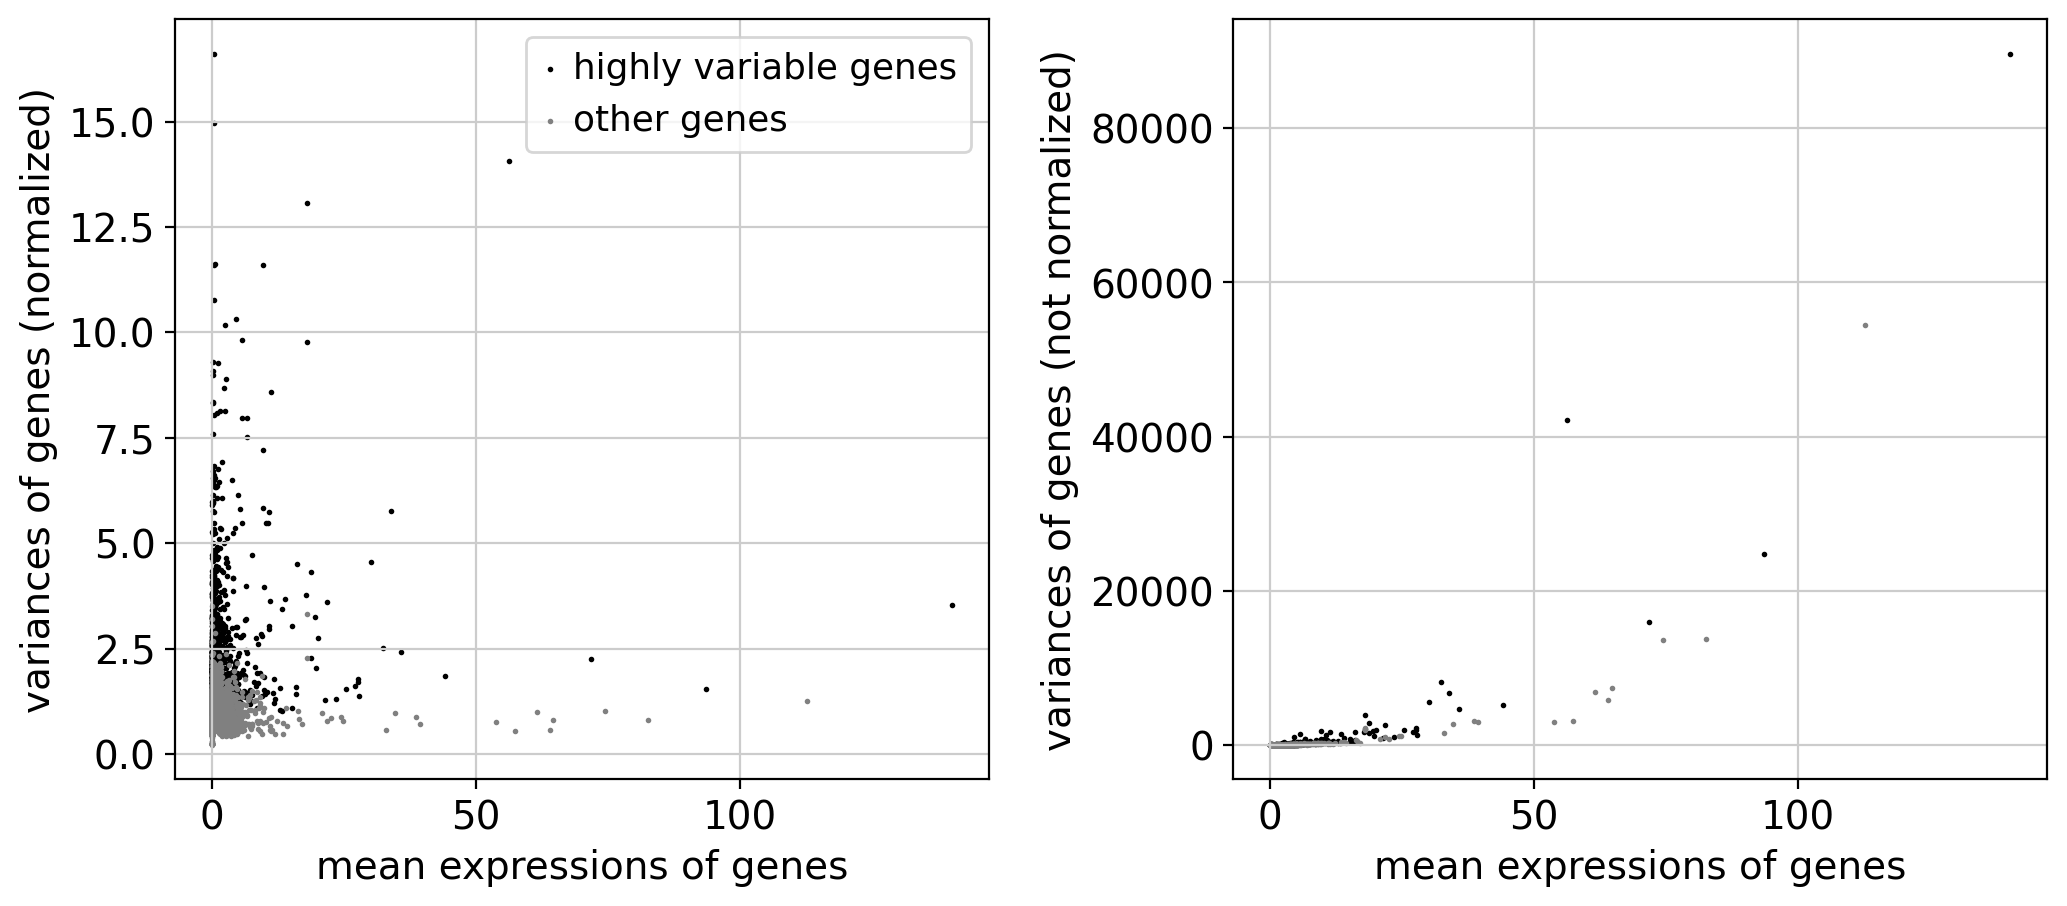

In [17]:
print(f"Identifying {N_HVG} HVGs on inner concat "
      f"({adata_inner.n_vars:,} shared genes) …")

# Check if a batch column is provided and exists in obs
use_batch = (HVGs_BATCH_COL is not None) and (HVGs_BATCH_COL in adata_inner.obs)

if use_batch and adata_inner.obs[HVGs_BATCH_COL].nunique() > 1:
    print(f"Running HVG with batch key: {HVGs_BATCH_COL}")
    sc.pp.highly_variable_genes(
        adata_inner,
        n_top_genes = N_HVG,
        flavor      = HVG_FLAVOR,
        batch_key   = HVGs_BATCH_COL,
        subset      = False,
    )
else:
    # Logic for when HVGs_BATCH_COL is None OR there is only 1 unique batch
    reason = "no batch column provided" if not use_batch else "only one unique batch found"
    print(f"WARNING: Running HVG without stratification ({reason}).")
    
    sc.pp.highly_variable_genes(
        adata_inner,
        n_top_genes = N_HVG,
        flavor      = HVG_FLAVOR,
        subset      = False,
    )

inner_genes_set = set(adata_inner.var_names)
hvg_set         = set(adata_inner.var_names[adata_inner.var.highly_variable])
print(f"HVGs selected: {len(hvg_set)}")
sc.pl.highly_variable_genes(adata_inner)

In [18]:
adata_hvg = adata_inner[:, adata_inner.var.highly_variable].copy()
del adata_inner
gc.collect()
print(f"adata_hvg (HVGs only): {adata_hvg}")

adata_hvg (HVGs only): AnnData object with n_obs × n_vars = 68198 × 2000
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'L3'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'varianc

## 5 · Batch correction with scVI

In [19]:
adata_hvg.obs[DONOR_COL] = adata_hvg.obs[DONOR_COL].astype(str)

In [22]:
scvi.settings.seed = RANDOM_SEED

if DONOR_COL not in adata_hvg.obs.columns:
    raise ValueError(f"Column '{DONOR_COL}' not found. Available: {adata_hvg.obs.columns.tolist()}")

print(f"Number of donors: {adata_hvg.obs[DONOR_COL].nunique()}")
print(f"Number of datasets: {adata_hvg.obs[DATASET_COL].nunique()}")

scvi.model.SCVI.setup_anndata(
    adata_hvg,
    batch_key                  = DATASET_COL,
    categorical_covariate_keys = [DONOR_COL, CELL_CYCLE_PHASE],
)

model = scvi.model.SCVI(
    adata_hvg,
    n_latent        = N_LATENT,
    n_layers        = N_LAYERS,
    gene_likelihood = GENE_LIKELIHOOD,
    dispersion      = DISPERSION
)
model

Seed set to 42


Number of donors: 254
Number of datasets: 27


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 60, n_layers: 1, dropout_rate: 0.1, dispersion: gene-batch, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [23]:
model.train(
    max_epochs     = MAX_EPOCHS,
    early_stopping = EARLY_STOPPING,
)
model.save(SCVI_MODEL_DIR, overwrite=True)
print(f"Model saved → {SCVI_MODEL_DIR}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-80GB MIG 1g.10gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-GPU-65984e58-2b6b-21f8-41cd-7854ff83d259/9/0]


Epoch 200/200: 100%|██████████| 200/200 [12:30<00:00,  3.60s/it, v_num=1, train_loss=1.25e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [12:30<00:00,  3.75s/it, v_num=1, train_loss=1.25e+3]
Model saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/scvi_model_acrosslifespan_noHormones_immune_monomacscDC2_visualisation


Loading outer concat (union of genes) …
outer : 68,198 cells × 35,965 genes
X_scVI transferred: shape (68198, 60)
in_inner: 15,338 genes  |  in_hvg: 2,000 genes


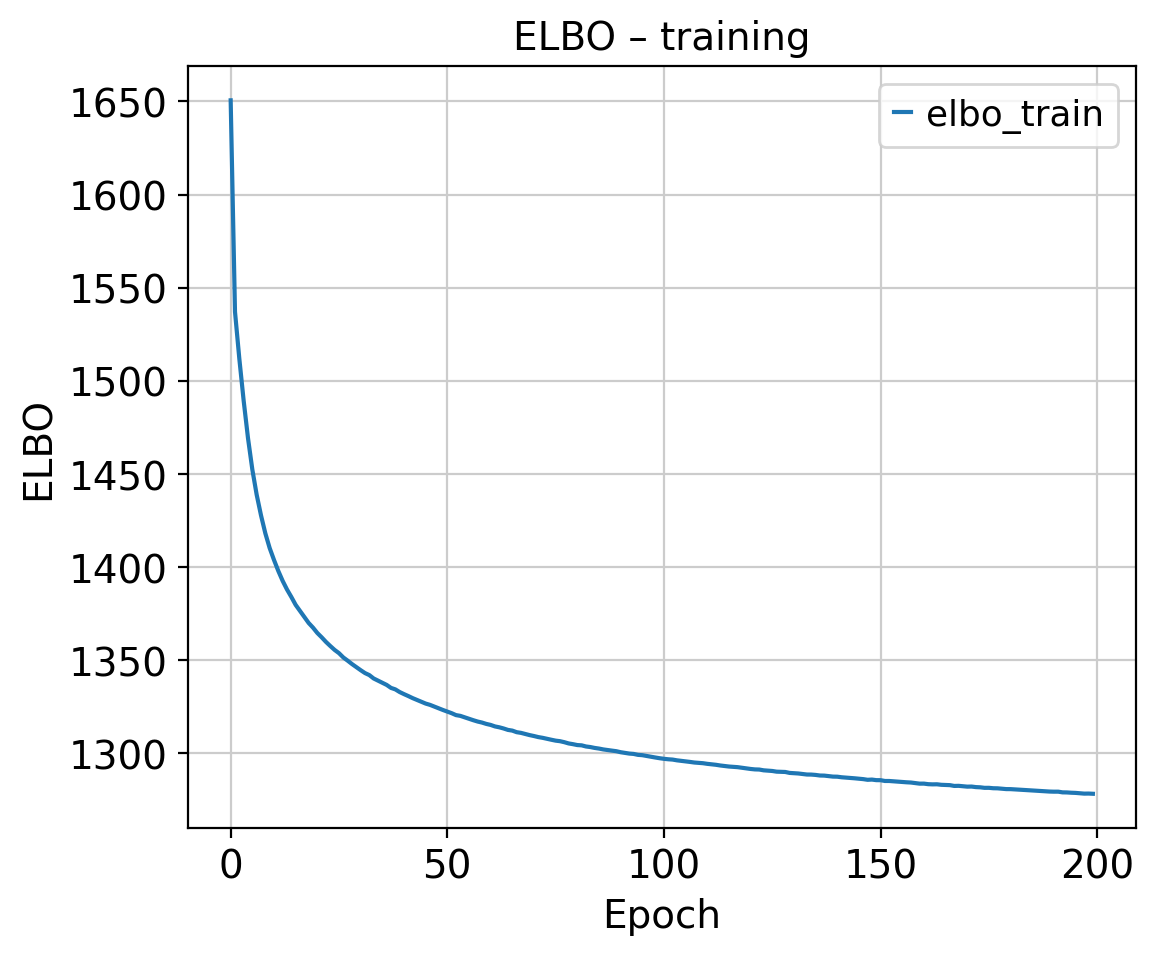

In [24]:
X_scVI = model.get_latent_representation()

del adata_hvg
gc.collect()

print("Loading outer concat (union of genes) …")
adata = ad.read_h5ad(CONCAT_H5AD_OUTER)

# ── Guard against duplicate barcodes ─────────────────────────────────────────
dup_mask = adata.obs_names.duplicated()
if dup_mask.any():
    n_dup = int(dup_mask.sum())
    print(f"WARNING: {n_dup} duplicate barcodes — deduplicating (keeping first).")
    adata = adata[~dup_mask].copy()

# ── Fix sparse matrix dtype mismatch ─────────────────────────────────────────
if sp.issparse(adata.X) and adata.X.indptr.dtype != adata.X.indices.dtype:
    target_dtype = np.result_type(adata.X.indptr.dtype, adata.X.indices.dtype)
    print(f"Fixing sparse dtype mismatch: indptr={adata.X.indptr.dtype}, "
          f"indices={adata.X.indices.dtype} → {target_dtype}")
    adata.X.indptr  = adata.X.indptr.astype(target_dtype)
    adata.X.indices = adata.X.indices.astype(target_dtype)

print(f"outer : {adata.n_obs:,} cells × {adata.n_vars:,} genes")

adata.obsm["X_scVI"]         = X_scVI
adata.var["in_inner"]        = adata.var_names.isin(inner_genes_set)
adata.var["in_hvg"]          = adata.var_names.isin(hvg_set)
adata.var["highly_variable"] = adata.var["in_hvg"]

del X_scVI
print(f"X_scVI transferred: shape {adata.obsm['X_scVI'].shape}")
print(f"in_inner: {adata.var['in_inner'].sum():,} genes  |  in_hvg: {adata.var['in_hvg'].sum():,} genes")

model.history["elbo_train"].plot()
plt.title("ELBO – training")
plt.ylabel("ELBO")
plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scvi_acrosslifespan_noHormones_immune_visualisation_elbo.png"), dpi=150)
plt.show()

## 6 · KNN graph, UMAP and Leiden clustering

In [25]:
import numba

print("Numba threads available:", numba.get_num_threads())
print("Numba config NUM_THREADS:", numba.config.NUMBA_NUM_THREADS)
print("CPUs visible to OS:", os.cpu_count())
print("CPUs in affinity mask:", len(os.sched_getaffinity(0)))
os.sched_setaffinity(0, range(64))
print("CPUs in affinity mask:", len(os.sched_getaffinity(0)))

from pynndescent import PyNNDescentTransformer

transformer = PyNNDescentTransformer(
    n_neighbors=N_NEIGHBORS,
    metric="euclidean",
    n_jobs=None,   # explicitly limit to 1
    random_state=RANDOM_SEED,
)

Numba threads available: 1
Numba config NUM_THREADS: 1
CPUs visible to OS: 64
CPUs in affinity mask: 1
CPUs in affinity mask: 1


In [26]:
_use_rapids = False
try:
    import rapids_singlecell as rsc
    import cupy as cp
    rsc.get.anndata_to_GPU(adata)
    rsc.pp.neighbors(
        adata,
        n_neighbors = N_NEIGHBORS+1,
        use_rep     = "X_scVI",
        algorithm   = "cagra",
        metric      = "euclidean",
    )
    rsc.get.anndata_to_CPU(adata)
    _use_rapids = True
    print("KNN computed with CAGRA (rapids_singlecell, GPU).")
except ImportError:
    print("rapids_singlecell not available — falling back to scanpy (pynndescent).")

if not _use_rapids:
    sc.pp.neighbors(
        adata,
        n_neighbors  = N_NEIGHBORS,
        use_rep      = "X_scVI",
        method       = "umap",
        # metric       = "euclidean",
        # random_state = RANDOM_SEED,
        transformer= transformer, # New, test with more cores to initialize jupyterlab
    )
    print("KNN computed with pynndescent (scanpy, CPU).")

rapids_singlecell not available — falling back to scanpy (pynndescent).
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:45)
KNN computed with pynndescent (scanpy, CPU).


In [27]:
sc.tl.umap(adata, random_state=RANDOM_SEED)
print("UMAP coordinates stored in adata.obsm['X_umap'].")

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:11)
UMAP coordinates stored in adata.obsm['X_umap'].


In [28]:
# if _use_rapids:
#     rsc.tl.leiden(
#         adata,
#         resolution   = LEIDEN_RESOLUTION,
#         random_state = RANDOM_SEED,
#         key_added    = "leiden",
#     )
# else:
#     sc.tl.leiden(
#         adata,
#         resolution   = LEIDEN_RESOLUTION,
#         random_state = RANDOM_SEED,
#         key_added    = "leiden",
#         flavor       = "igraph",
#         n_iterations = 2,
#         directed     = False,
#     )
# print(f"Leiden clusters (res={LEIDEN_RESOLUTION}): {adata.obs['leiden'].nunique()} clusters")
# print(adata.obs["leiden"].value_counts().sort_index())

## 7 · Save integrated object

In [29]:
adata.write_h5ad(INTEGRATED_H5AD)
print(f"Integrated object saved → {INTEGRATED_H5AD}")
print(adata)

Integrated object saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/integrated_scvi_acrosslifespan_noHormones_immune_monomacscDC2_visualisation.h5ad
AnnData object with n_obs × n_vars = 68198 × 35965
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample